# Tiền xử lý dữ liệu - Scaling

Notebook này so sánh một vài cách scale dữ liệu số cho bài toán dự đoán tuổi Abalone, sau đó chọn cách phù hợp để dùng cho các bước sau.

## 1. Import thư viện

In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, RobustScaler, StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

## 2. Nạp dữ liệu và kiểm tra nhanh

In [ ]:
đường_dẫn_ứng_viên = [
    Path('../../data/raw/abalone.csv'),
    Path('../data/raw/abalone.csv'),
    Path('data/raw/abalone.csv'),
    Path('AbaloneAge/data/raw/abalone.csv'),
]

đường_dẫn_dữ_liệu = None
for p in đường_dẫn_ứng_viên:
    p_đầy_đủ = p.resolve()
    if p_đầy_đủ.exists():
        đường_dẫn_dữ_liệu = p_đầy_đủ
        break

if đường_dẫn_dữ_liệu is None:
    raise FileNotFoundError(
        'Không tìm thấy file abalone.csv. Đã thử: ' + ', '.join(str(p.resolve()) for p in đường_dẫn_ứng_viên)
    )

df = pd.read_csv(đường_dẫn_dữ_liệu, header=None)
df.columns = [
    'sex', 'length', 'diameter', 'height',
    'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight', 'rings'
]

print('Đường dẫn dữ liệu:', đường_dẫn_dữ_liệu)
print('Kích thước:', df.shape)
print('\nKiểu dữ liệu:')
print(df.dtypes)
print('\nSố giá trị thiếu:')
print(df.isnull().sum())
df.head()

Duong dan du lieu: C:\Users\Admin\Documents\GitHub\TNTT_Repo_Abalone6\AbaloneAge\data\raw\abalone.csv
Kich thuoc: (4177, 9)

Kieu du lieu:
sex                object
length            float64
diameter          float64
height            float64
whole_weight      float64
shucked_weight    float64
viscera_weight    float64
shell_weight      float64
rings               int64
dtype: object

So gia tri thieu:
sex               0
length            0
diameter          0
height            0
whole_weight      0
shucked_weight    0
viscera_weight    0
shell_weight      0
rings             0
dtype: int64


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 3. Chia train, validation, test

In [3]:
X = df.drop(columns=['rings'])
y = df['rings']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test:', X_test.shape, y_test.shape)

Train: (2923, 8) (2923,)
Validation: (627, 8) (627,)
Test: (627, 8) (627,)


## 4. Xem phân phối trước khi scale

                    mean       std     min     max
length          0.523992  0.120093  0.0750  0.8150
diameter        0.407881  0.099240  0.0550  0.6500
height          0.139516  0.041827  0.0000  1.1300
whole_weight    0.828742  0.490389  0.0020  2.8255
shucked_weight  0.359367  0.221963  0.0010  1.4880
viscera_weight  0.180594  0.109614  0.0005  0.7600
shell_weight    0.238831  0.139203  0.0015  1.0050


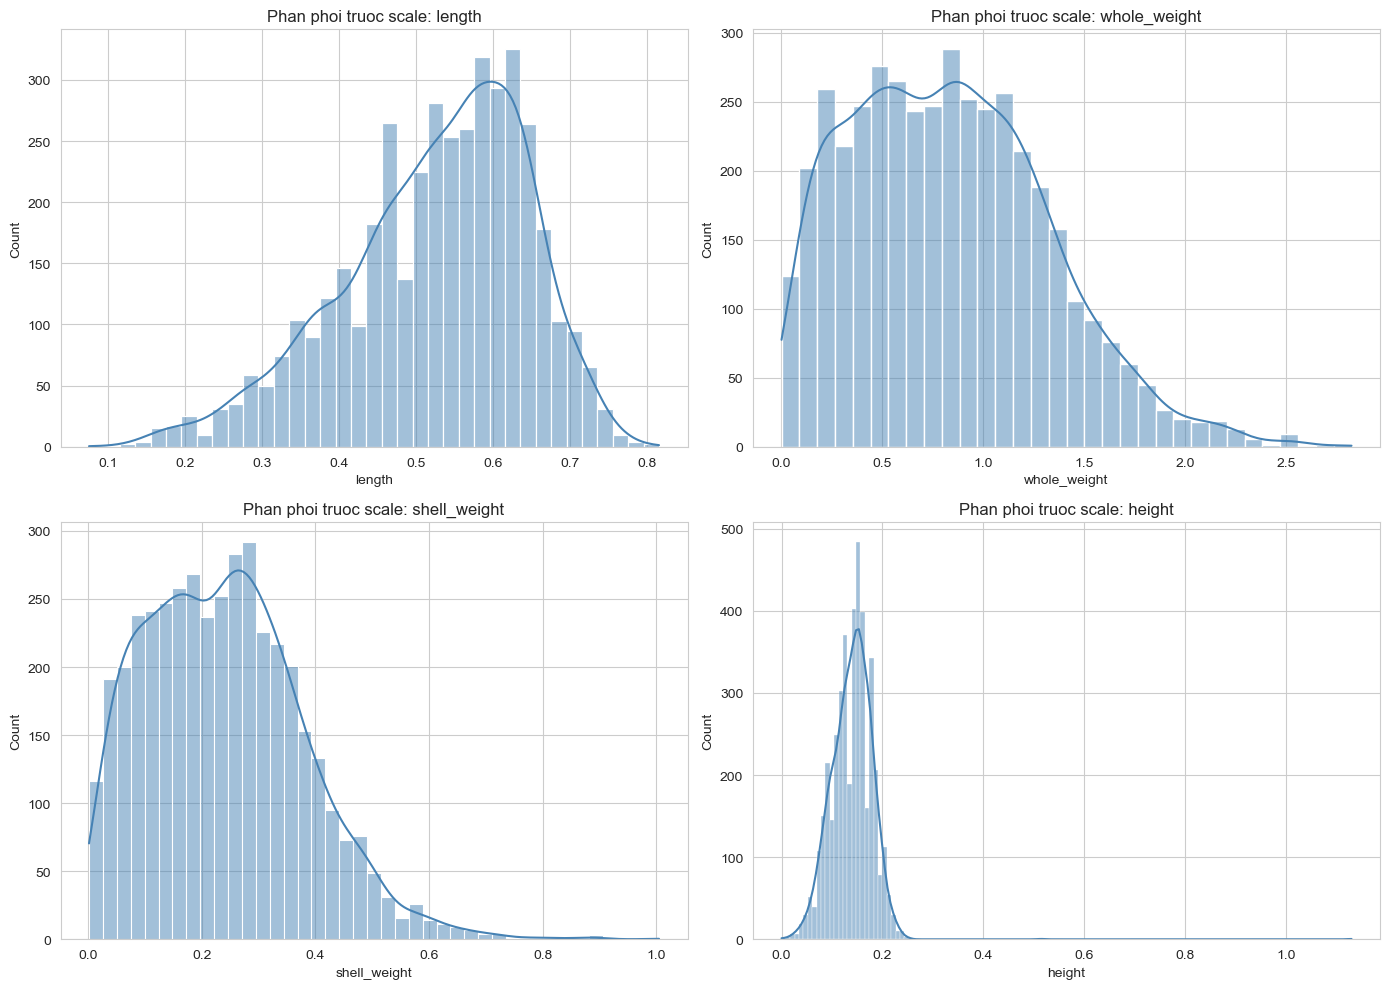

In [ ]:
cột_số = ['length', 'diameter', 'height', 'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight']

print(df[cột_số].describe().T[['mean', 'std', 'min', 'max']])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cột_vẽ = ['length', 'whole_weight', 'shell_weight', 'height']
for ax, cột in zip(axes.ravel(), cột_vẽ):
    sns.histplot(df[cột], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Phân phối trước scale: {cột}')

plt.tight_layout()
plt.show()

## 5. Tạo pipeline tiền xử lý

In [ ]:
cột_hạng_mục = ['sex']

tiền_xử_lý_chung = ColumnTransformer(transformers=[
    ('so', Pipeline(steps=[
        ('dien_khuyet', SimpleImputer(strategy='median')),
    ]), cột_số),
    ('hang_muc', Pipeline(steps=[
        ('dien_khuyet', SimpleImputer(strategy='most_frequent')),
        ('one_hot', OneHotEncoder(handle_unknown='ignore'))
    ]), cột_hạng_mục),
])

các_scaler = {
    'standard': StandardScaler(),
    'minmax': MinMaxScaler(),
    'robust': RobustScaler(),
}

print('Đã tạo xong tiền xử lý chung và danh sách scaler.')

Da tao xong tien xu ly chung va danh sach scaler.


## 6. So sánh các cách scale bằng Ridge

In [ ]:
kết_quả = []
dòng_hình = []

for tên_scaler, scaler in các_scaler.items():
    tiền_xử_lý = ColumnTransformer(transformers=[
        ('so', Pipeline(steps=[
            ('dien_khuyet', SimpleImputer(strategy='median')),
            ('scale', scaler),
        ]), cột_số),
        ('hang_muc', Pipeline(steps=[
            ('dien_khuyet', SimpleImputer(strategy='most_frequent')),
            ('one_hot', OneHotEncoder(handle_unknown='ignore'))
        ]), cột_hạng_mục),
    ])

    X_train_txl = tiền_xử_lý.fit_transform(X_train)
    X_val_txl = tiền_xử_lý.transform(X_val)

    mô_hình = Ridge(alpha=1.0)
    mô_hình.fit(X_train_txl, y_train)
    dự_đoán_val = mô_hình.predict(X_val_txl)

    mae = mean_absolute_error(y_val, dự_đoán_val)
    rmse = np.sqrt(mean_squared_error(y_val, dự_đoán_val))
    r2 = r2_score(y_val, dự_đoán_val)

    kết_quả.append({
        'scaler': tên_scaler,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
    })

    dòng_hình.append({
        'scaler': tên_scaler,
        'tiền_xử_lý': tiền_xử_lý,
        'mô_hình': mô_hình,
    })

bảng_kết_quả = pd.DataFrame(kết_quả).sort_values(by='RMSE')
bảng_kết_quả

,scaler,MAE,RMSE,R2
1,minmax,1.617685,2.209271,0.513512
2,robust,1.619604,2.221017,0.508326
0,standard,1.620732,2.224273,0.506883


## 7. Trực quan hóa kết quả so sánh

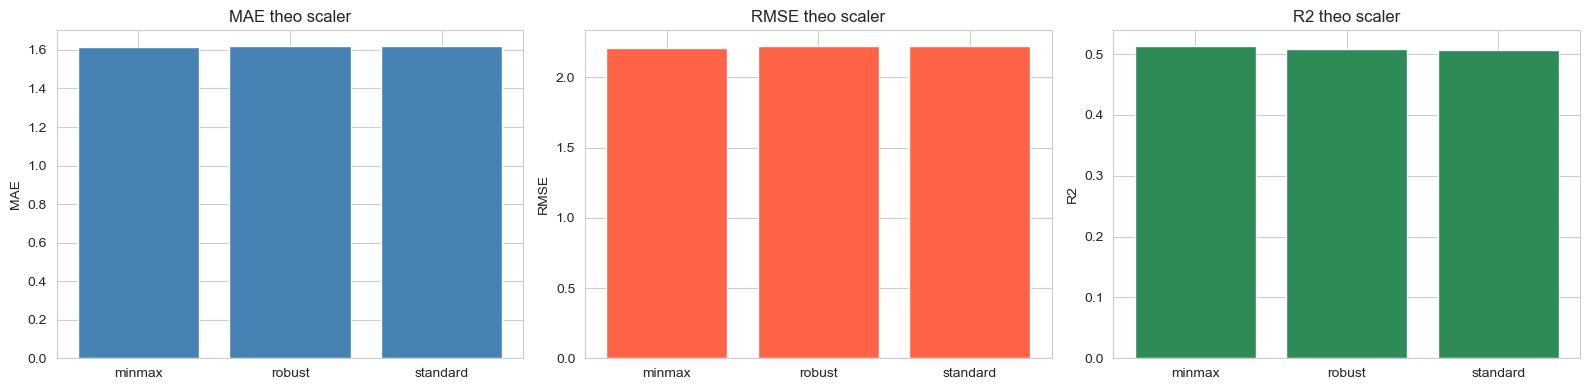

Da luu hinh: 02_preprocessing_scaling_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(bảng_kết_quả['scaler'], bảng_kết_quả['MAE'], color='steelblue')
axes[0].set_title('MAE theo scaler')
axes[0].set_ylabel('MAE')

axes[1].bar(bảng_kết_quả['scaler'], bảng_kết_quả['RMSE'], color='tomato')
axes[1].set_title('RMSE theo scaler')
axes[1].set_ylabel('RMSE')

axes[2].bar(bảng_kết_quả['scaler'], bảng_kết_quả['R2'], color='seagreen')
axes[2].set_title('R2 theo scaler')
axes[2].set_ylabel('R2')

plt.tight_layout()
đường_dẫn_hình = Path('../../outputs/figures').resolve()
đường_dẫn_hình.mkdir(parents=True, exist_ok=True)
plt.savefig(đường_dẫn_hình / '02_preprocessing_scaling_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Đã lưu hình: 02_preprocessing_scaling_comparison.png')

## 8. Chọn scaler tốt nhất và scale dữ liệu cuối

In [ ]:
tên_scaler_tốt_nhất = bảng_kết_quả.iloc[0]['scaler']
print('Scaler tốt nhất theo validation:', tên_scaler_tốt_nhất)

scaler_tốt = các_scaler[tên_scaler_tốt_nhất]
tiền_xử_lý_tốt = ColumnTransformer(transformers=[
    ('so', Pipeline(steps=[
        ('dien_khuyet', SimpleImputer(strategy='median')),
        ('scale', scaler_tốt),
    ]), cột_số),
    ('hang_muc', Pipeline(steps=[
        ('dien_khuyet', SimpleImputer(strategy='most_frequent')),
        ('one_hot', OneHotEncoder(handle_unknown='ignore'))
    ]), cột_hạng_mục),
])

X_train_scaled = tiền_xử_lý_tốt.fit_transform(X_train)
X_val_scaled = tiền_xử_lý_tốt.transform(X_val)
X_test_scaled = tiền_xử_lý_tốt.transform(X_test)

tên_đặc_trưng = tiền_xử_lý_tốt.get_feature_names_out()
df_train_scaled = pd.DataFrame(X_train_scaled, columns=tên_đặc_trưng, index=X_train.index)
df_val_scaled = pd.DataFrame(X_val_scaled, columns=tên_đặc_trưng, index=X_val.index)
df_test_scaled = pd.DataFrame(X_test_scaled, columns=tên_đặc_trưng, index=X_test.index)

df_train_scaled.head()

Scaler tot nhat theo validation: minmax


,so__length,so__diameter,so__height,so__whole_weight,so__shucked_weight,so__viscera_weight,so__shell_weight,hang_muc__sex_F,hang_muc__sex_I,hang_muc__sex_M
2830,0.608108,0.630252,0.119469,0.298034,0.290182,0.236340,0.179372,1.0,0.0,0.0
925,0.479730,0.453782,0.088496,0.128387,0.105245,0.107966,0.103139,0.0,1.0,0.0
3845,0.513514,0.495798,0.092920,0.146627,0.108608,0.127057,0.143000,0.0,0.0,1.0
547,0.175676,0.168067,0.039823,0.014344,0.010760,0.006583,0.013951,0.0,0.0,1.0
2259,0.695946,0.689076,0.141593,0.389056,0.339610,0.331797,0.292476,1.0,0.0,0.0


## 9. Đánh giá lại trên test

In [ ]:
mô_hình_cuối = Ridge(alpha=1.0)
mô_hình_cuối.fit(X_train_scaled, y_train)
dự_đoán_test = mô_hình_cuối.predict(X_test_scaled)

mae_test = mean_absolute_error(y_test, dự_đoán_test)
rmse_test = np.sqrt(mean_squared_error(y_test, dự_đoán_test))
r2_test = r2_score(y_test, dự_đoán_test)

print('Kết quả trên test:')
print(f'MAE : {mae_test:.4f}')
print(f'RMSE: {rmse_test:.4f}')
print(f'R2  : {r2_test:.4f}')

Ket qua tren test:
MAE : 1.5591
RMSE: 2.1753
R2  : 0.5390


## 10. Lưu dữ liệu đã scale và kết quả

In [ ]:
thư_mục_processed = Path('../../data/processed').resolve()
thư_mục_metrics = Path('../../outputs/metrics').resolve()
thư_mục_processed.mkdir(parents=True, exist_ok=True)
thư_mục_metrics.mkdir(parents=True, exist_ok=True)

df_train_scaled.to_csv(thư_mục_processed / 'abalone_train_scaled.csv', index=False)
df_val_scaled.to_csv(thư_mục_processed / 'abalone_val_scaled.csv', index=False)
df_test_scaled.to_csv(thư_mục_processed / 'abalone_test_scaled.csv', index=False)

bảng_kết_quả.to_csv(thư_mục_metrics / '02_preprocessing_scaling_comparison.csv', index=False)

tổng_tắt = {
    'phương_pháp': 'scaling',
    'scaler_tốt_nhất': tên_scaler_tốt_nhất,
    'validation': bảng_kết_quả.iloc[0].to_dict(),
    'test': {
        'MAE': mae_test,
        'RMSE': rmse_test,
        'R2': r2_test,
    },
    'số_đặc_trưng_sau_scale': int(len(tên_đặc_trưng)),
}

with open(thư_mục_metrics / '02_preprocessing_scaling_summary.json', 'w', encoding='utf-8') as f:
    json.dump(tổng_tắt, f, ensure_ascii=False, indent=2)

print('Đã lưu: abalone_train_scaled.csv')
print('Đã lưu: abalone_val_scaled.csv')
print('Đã lưu: abalone_test_scaled.csv')
print('Đã lưu: 02_preprocessing_scaling_comparison.csv')
print('Đã lưu: 02_preprocessing_scaling_summary.json')

Da luu: abalone_train_scaled.csv
Da luu: abalone_val_scaled.csv
Da luu: abalone_test_scaled.csv
Da luu: 02_preprocessing_scaling_comparison.csv
Da luu: 02_preprocessing_scaling_summary.json
